In [8]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot

import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()

wr20_n19_ee = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/combined_22_23/merged/sig/WR2000N100MM.root"
file1 = uproot.open(wr20_n19_ee)
events = file1["Central"]
lhe_pt = events["Cutflow_for_reseolved_SR"].values()


In [9]:
print(lhe_pt)

[ 0.00000000e+00 -1.07869679e+09 -1.07869679e+09 -1.63900526e+08
 -1.62727953e+08 -3.55377934e+07 -3.55004328e+07 -3.55004328e+07
 -3.55004328e+07 -3.26778361e+07]


In [11]:
import json
import re
from pathlib import Path

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot

json_path = Path('WRtoNELtoEEJJ_cross_sections.json')
root_dir = Path('/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig/')
max_wr_mass = 8000

channels = ['ee', 'mumu']
regions = ['resolved', 'boosted', 'combined']
channel_map = {'EE': 'ee', 'MM': 'mumu'}

json_pattern = re.compile(r'WRtoNELtoEEJJ_WR(?P<wr>\d+)_N(?P<n>\d+)\.out')
root_pattern = re.compile(r'WR(?P<wr>\d+)N(?P<n>\d+)(?P<ch>EE|MM)\.root')

root_rows = []
for root_path in sorted(root_dir.glob('WR*N*EE.root')) + sorted(root_dir.glob('WR*N*MM.root')):
    match = root_pattern.fullmatch(root_path.name)
    if not match:
        continue

    wr_mass = int(match.group('wr'))
    n_mass = int(match.group('n'))
    if wr_mass > max_wr_mass:
        continue

    root_rows.append({
        'wr_mass': wr_mass,
        'n_mass': n_mass,
        'channel': channel_map[match.group('ch')],
        'root_path': str(root_path),
    })

root_df = pd.DataFrame(root_rows).drop_duplicates().sort_values(['wr_mass', 'n_mass', 'channel']).reset_index(drop=True)
allowed_mass_points = set(zip(root_df['wr_mass'], root_df['n_mass']))

with open(json_path) as f:
    xsec_data = json.load(f)

xsec_rows = []
for sample_name, values in xsec_data.items():
    match = json_pattern.match(sample_name)
    if not match:
        continue

    wr_mass = int(match.group('wr'))
    n_mass = int(match.group('n'))
    if wr_mass > max_wr_mass:
        continue
    if (wr_mass, n_mass) not in allowed_mass_points:
        continue

    xsec_rows.append({
        'sample': sample_name,
        'wr_mass': wr_mass,
        'n_mass': n_mass,
        'cross_section_pb': values['cross_section_pb'],
        'uncertainty_pb': values.get('uncertainty_pb'),
    })

df = pd.DataFrame(xsec_rows).sort_values(['wr_mass', 'n_mass']).drop_duplicates(['wr_mass', 'n_mass']).reset_index(drop=True)

root_path_wide = root_df.pivot(index=['wr_mass', 'n_mass'], columns='channel', values='root_path').reset_index()
root_path_wide = root_path_wide.rename(columns={'ee': 'ee_root_path', 'mumu': 'mumu_root_path'})
df = df.merge(root_path_wide, on=['wr_mass', 'n_mass'], how='left')

for channel in channels:
    for region in regions:
        eff_col = f'eff_{channel}_{region}'
        weighted_col = f'xsec_times_eff_{channel}_{region}_pb'
        df[eff_col] = np.nan
        df[weighted_col] = np.nan

df[['wr_mass', 'n_mass', 'cross_section_pb', 'ee_root_path', 'mumu_root_path']].head()


,wr_mass,n_mass,cross_section_pb,ee_root_path,mumu_root_path
0,2000,100,0.1549,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...
1,2000,300,0.1497,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...
2,2000,500,0.1386,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...
3,2000,700,0.1195,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...
4,2000,900,0.1046,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...,/gv0/Users/achihwan/SKNanoOutput/Reproduce20_0...


In [12]:
boosted_hist_candidates = [
    'Central/Cutflow_for_Boosted_SR',
]

resolved_hist_candidates = [
    'Central/Cutflow_for_Resolved_SR',
    'Central/Cutflow_for_reseolved_SR',
]


def extract_efficiency_from_cutflow(root_path, hist_candidates, use_penultimate_bin=False):
    if pd.isna(root_path):
        return np.nan, np.nan, np.nan, None

    with uproot.open(root_path) as root_file:
        hist_name = next((name for name in hist_candidates if name in root_file), None)
        if hist_name is None:
            return np.nan, np.nan, np.nan, None

        values = root_file[hist_name].values(flow=False)
        if len(values) < 2:
            return np.nan, np.nan, np.nan, hist_name

        second_bin = float(values[1])
        numerator_bin = float(values[-2] if use_penultimate_bin and len(values) >= 2 else values[-1])
        efficiency = np.nan if second_bin <= 0 else numerator_bin / second_bin
        return efficiency, second_bin, numerator_bin, hist_name


def fill_efficiencies_from_root(df):
    df = df.copy()

    for row_idx, row in df.iterrows():
        for channel in channels:
            root_col = f'{channel}_root_path'
            root_path = row[root_col]

            resolved_eff, resolved_bin2, resolved_last, resolved_hist = extract_efficiency_from_cutflow(root_path, resolved_hist_candidates)
            boosted_eff, boosted_bin2, boosted_last, boosted_hist = extract_efficiency_from_cutflow(root_path, boosted_hist_candidates, use_penultimate_bin=True)

            df.at[row_idx, f'eff_{channel}_resolved'] = resolved_eff
            df.at[row_idx, f'eff_{channel}_boosted'] = boosted_eff

            df.at[row_idx, f'{channel}_resolved_bin2'] = resolved_bin2
            df.at[row_idx, f'{channel}_resolved_last_bin'] = resolved_last
            df.at[row_idx, f'{channel}_resolved_hist'] = resolved_hist

            df.at[row_idx, f'{channel}_boosted_bin2'] = boosted_bin2
            df.at[row_idx, f'{channel}_boosted_last_bin'] = boosted_last
            df.at[row_idx, f'{channel}_boosted_hist'] = boosted_hist

            if np.isnan(resolved_eff) and np.isnan(boosted_eff):
                combined_eff = np.nan
            else:
                combined_eff = np.nansum([resolved_eff, boosted_eff])

            df.at[row_idx, f'eff_{channel}_combined'] = combined_eff

    for channel in channels:
        for region in regions:
            eff_col = f'eff_{channel}_{region}'
            weighted_col = f'xsec_times_eff_{channel}_{region}_pb'
            df[weighted_col] = df['cross_section_pb'] * df[eff_col]

    return df


def plot_mass_map(df, value_col, title, cbar_label, cmap='viridis', logz=True, ax=None, norm=None):
    pivot = df.pivot(index='n_mass', columns='wr_mass', values=value_col).sort_index().sort_index(axis=1)
    masked = np.ma.masked_invalid(pivot.values)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    if norm is None:
        if logz:
            positive = df.loc[df[value_col] > 0, value_col].dropna()
            if len(positive) > 0:
                norm = colors.LogNorm(vmin=positive.min(), vmax=positive.max())

    mesh = ax.pcolormesh(
        pivot.columns.values,
        pivot.index.values,
        masked,
        shading='nearest',
        cmap=cmap,
        norm=norm,
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_xlabel('WR mass [GeV]')
    ax.set_ylabel('N mass [GeV]')
    ax.set_title(title)
    ax.grid(alpha=0.2)
    return fig, ax, mesh


def plot_six_efficiency_maps(df, value_kind='efficiency'):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    if value_kind == 'efficiency':
        logz = False
        cmap = 'magma'
        cbar_label = 'Efficiency'
    elif value_kind == 'xsec_times_eff':
        logz = True
        cmap = 'viridis'
        cbar_label = 'Cross section × efficiency [pb]'
    else:
        raise ValueError("value_kind must be 'efficiency' or 'xsec_times_eff'")

    # 전체 6개 플롯에 걸쳐 공통 color range 계산
    all_vals = []
    for channel in channels:
        for region in regions:
            if value_kind == 'efficiency':
                col = f'eff_{channel}_{region}'
            else:
                col = f'xsec_times_eff_{channel}_{region}_pb'
            vals = df[col].dropna()
            if logz:
                vals = vals[vals > 0]
            all_vals.append(vals)

    combined = pd.concat(all_vals)
    global_vmin = combined.min()
    global_vmax = combined.max()

    if logz:
        shared_norm = colors.LogNorm(vmin=global_vmin, vmax=global_vmax)
    else:
        shared_norm = plt.Normalize(vmin=global_vmin, vmax=global_vmax)

    last_mesh = None
    for row, channel in enumerate(channels):
        for col, region in enumerate(regions):
            ax = axes[row, col]

            if value_kind == 'efficiency':
                value_col = f'eff_{channel}_{region}'
                title = f'{channel} - {region} efficiency'
            else:
                value_col = f'xsec_times_eff_{channel}_{region}_pb'
                title = f'{channel} - {region} cross section × efficiency'

            pivot = df.pivot(index='n_mass', columns='wr_mass', values=value_col).sort_index().sort_index(axis=1)
            masked = np.ma.masked_invalid(pivot.values)

            mesh = ax.pcolormesh(
                pivot.columns.values,
                pivot.index.values,
                masked,
                shading='nearest',
                cmap=cmap,
                norm=shared_norm,
            )
            last_mesh = mesh

            if value_kind == 'efficiency':
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=shared_norm)
                for iy, n_val in enumerate(pivot.index.values):
                    for ix, wr_val in enumerate(pivot.columns.values):
                        val = pivot.values[iy, ix]
                        if np.isnan(val):
                            continue
                        rgba = sm.to_rgba(val)
                        lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                        txt_color = 'white' if lum < 0.5 else 'black'
                        ax.text(
                            wr_val, n_val,
                            f'{val*100:.1f}',
                            ha='center', va='center',
                            fontsize=5.5, color=txt_color, fontweight='bold',
                        )

            ax.set_xlabel('WR mass [GeV]')
            ax.set_ylabel('N mass [GeV]')
            ax.set_title(title)
            ax.grid(alpha=0.2)

    # 6개 subplot 공유 colorbar 하나만 추가
    fig.colorbar(last_mesh, ax=axes, label=cbar_label, shrink=0.6)

    return fig, axes


In [13]:
df = fill_efficiencies_from_root(df)

summary_columns = [
    'wr_mass', 'n_mass', 'cross_section_pb',
    'eff_ee_resolved', 'eff_ee_boosted', 'eff_ee_combined',
    'eff_mumu_resolved', 'eff_mumu_boosted', 'eff_mumu_combined',
]

print(f'Number of mass points used: {len(df)}')
display(df[summary_columns].head(10))


Number of mass points used: 100


,wr_mass,n_mass,cross_section_pb,eff_ee_resolved,eff_ee_boosted,eff_ee_combined,eff_mumu_resolved,eff_mumu_boosted,eff_mumu_combined
0,2000,100,0.154900,0.014800,0.192043,0.206843,0.029586,0.465086,0.494671
1,2000,300,0.149700,0.259757,0.143529,0.403286,0.377357,0.105714,0.483071
2,2000,500,0.138600,0.392043,0.064186,0.456229,0.532443,0.037186,0.569629
3,2000,700,0.119500,0.444443,0.038114,0.482557,0.593457,0.019729,0.613186
4,2000,900,0.104600,0.466232,0.029449,0.495681,0.621507,0.012672,0.634179
5,2000,1100,0.082390,0.467400,0.027914,0.495314,0.623015,0.013627,0.636642
6,2000,1300,0.059840,0.457970,0.028134,0.486104,0.606940,0.014597,0.621537
7,2000,1500,0.036470,0.429686,0.029171,0.458857,0.571985,0.016299,0.588284
8,2000,1700,0.015850,0.360000,0.027900,0.387900,0.476914,0.019929,0.496843
9,2000,1900,0.002704,0.196043,0.021043,0.217086,0.261224,0.018627,0.279851


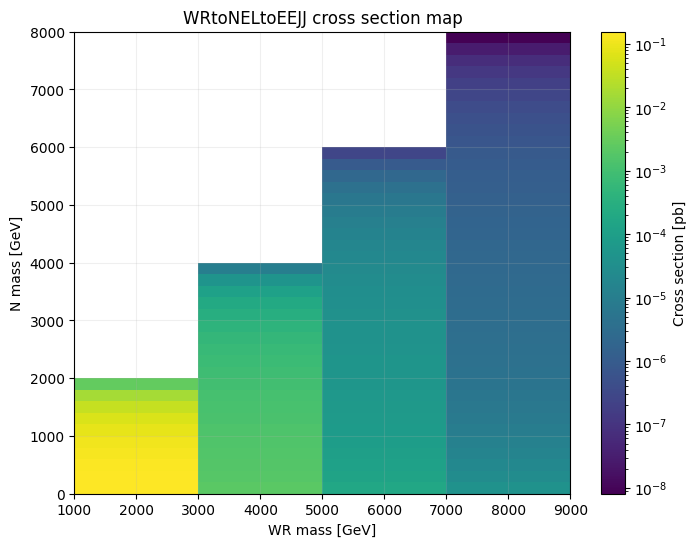

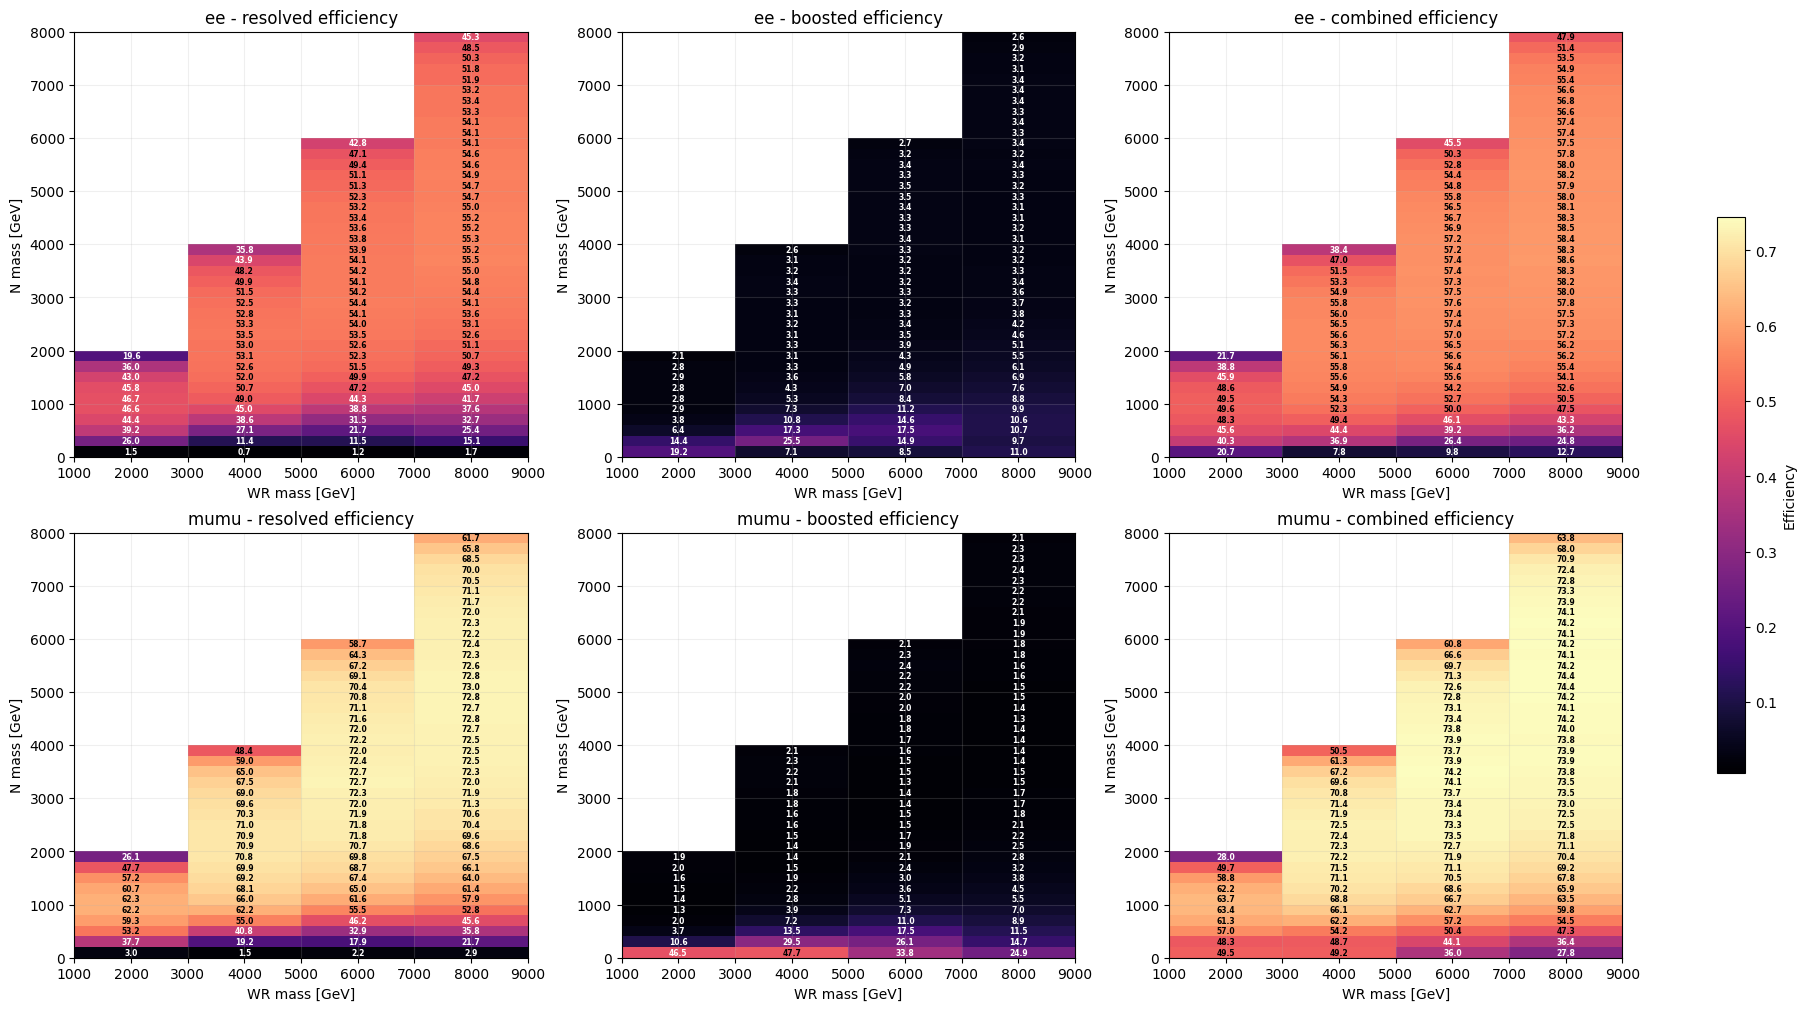

In [12]:
# cross section map (only mass points found in root_dir, and WR <= 6000)
plot_mass_map(
    df=df,
    value_col='cross_section_pb',
    title='WRtoNELtoEEJJ cross section map',
    cbar_label='Cross section [pb]',
    cmap='viridis',
    logz=True,
)
plt.show()

# efficiency 6개 플롯
fig, axes = plot_six_efficiency_maps(df, value_kind='efficiency')
plt.show()


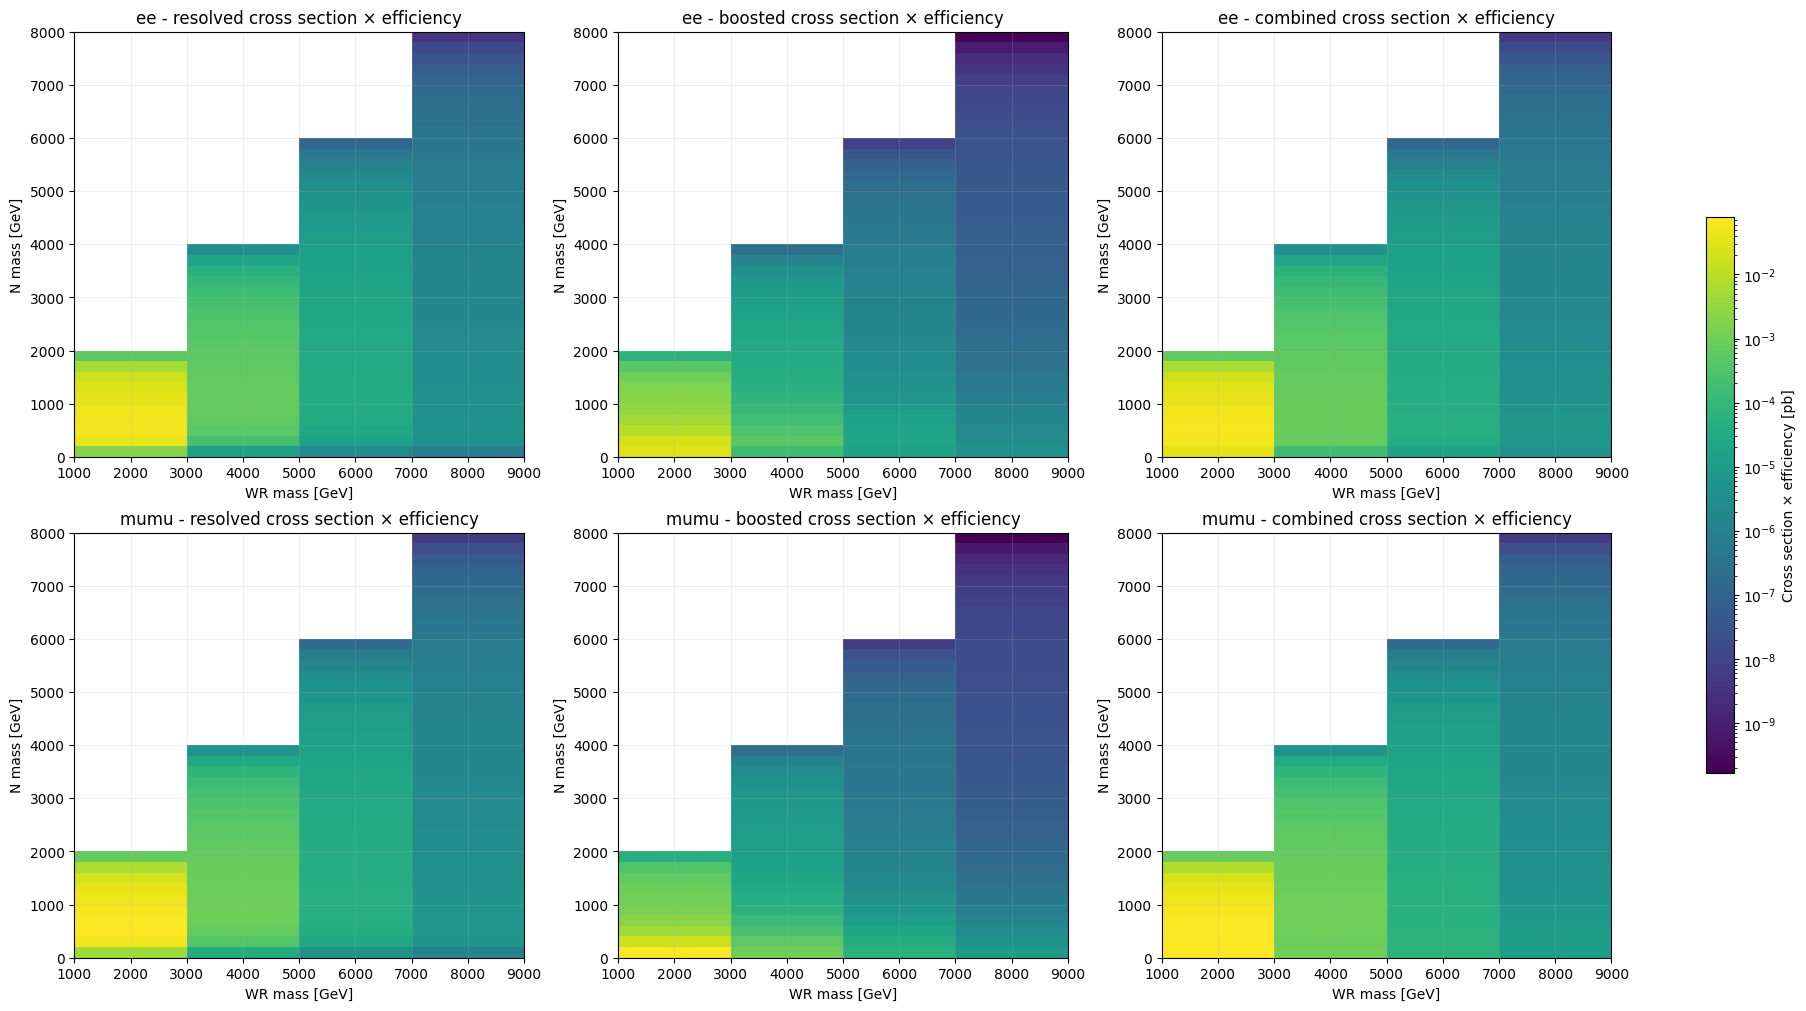

,wr_mass,n_mass,ee_resolved_bin2,ee_resolved_last_bin,ee_boosted_bin2,ee_boosted_last_bin,mumu_resolved_bin2,mumu_resolved_last_bin,mumu_boosted_bin2,mumu_boosted_last_bin
0,2000,100,2756.290659,40.793102,2756.290659,529.325933,2756.290659,81.546828,2756.290659,1281.911410
1,2000,300,2663.761787,691.931151,2663.761787,382.325924,2663.761787,1005.189537,2663.761787,281.597675
2,2000,500,2466.248609,966.875151,2466.248609,158.297929,2466.248609,1313.136456,2466.248609,91.709216
3,2000,700,2126.382999,945.055736,2126.382999,81.045569,2126.382999,1261.917179,2126.382999,41.950499
4,2000,900,1861.252399,867.775213,1861.252399,54.812534,1861.252395,1156.782254,1861.252395,23.585124
5,2000,1100,1466.047745,685.230716,1466.047745,40.923676,1466.047663,913.369576,1466.047663,19.977635
6,2000,1300,1064.793011,487.643414,1064.793011,29.957236,1064.793011,646.265788,1064.793011,15.542799
7,2000,1500,648.947153,278.843321,648.947153,18.930716,648.947192,371.188108,648.947192,10.576871
8,2000,1700,282.034902,101.532565,282.034902,7.868774,282.034902,134.506474,282.034902,5.620553
9,2000,1900,48.114980,9.432598,48.114980,1.012477,48.114977,12.568781,48.114977,0.896231


In [15]:
# xsec × efficiency 6개 플롯
fig, axes = plot_six_efficiency_maps(df, value_kind='xsec_times_eff')
plt.show()

# 필요하면 특정 mass point의 cutflow bin 값도 확인 가능
debug_columns = [
    'wr_mass', 'n_mass',
    'ee_resolved_bin2', 'ee_resolved_last_bin', 'ee_boosted_bin2', 'ee_boosted_last_bin',
    'mumu_resolved_bin2', 'mumu_resolved_last_bin', 'mumu_boosted_bin2', 'mumu_boosted_last_bin',
]
display(df[debug_columns].head(10))


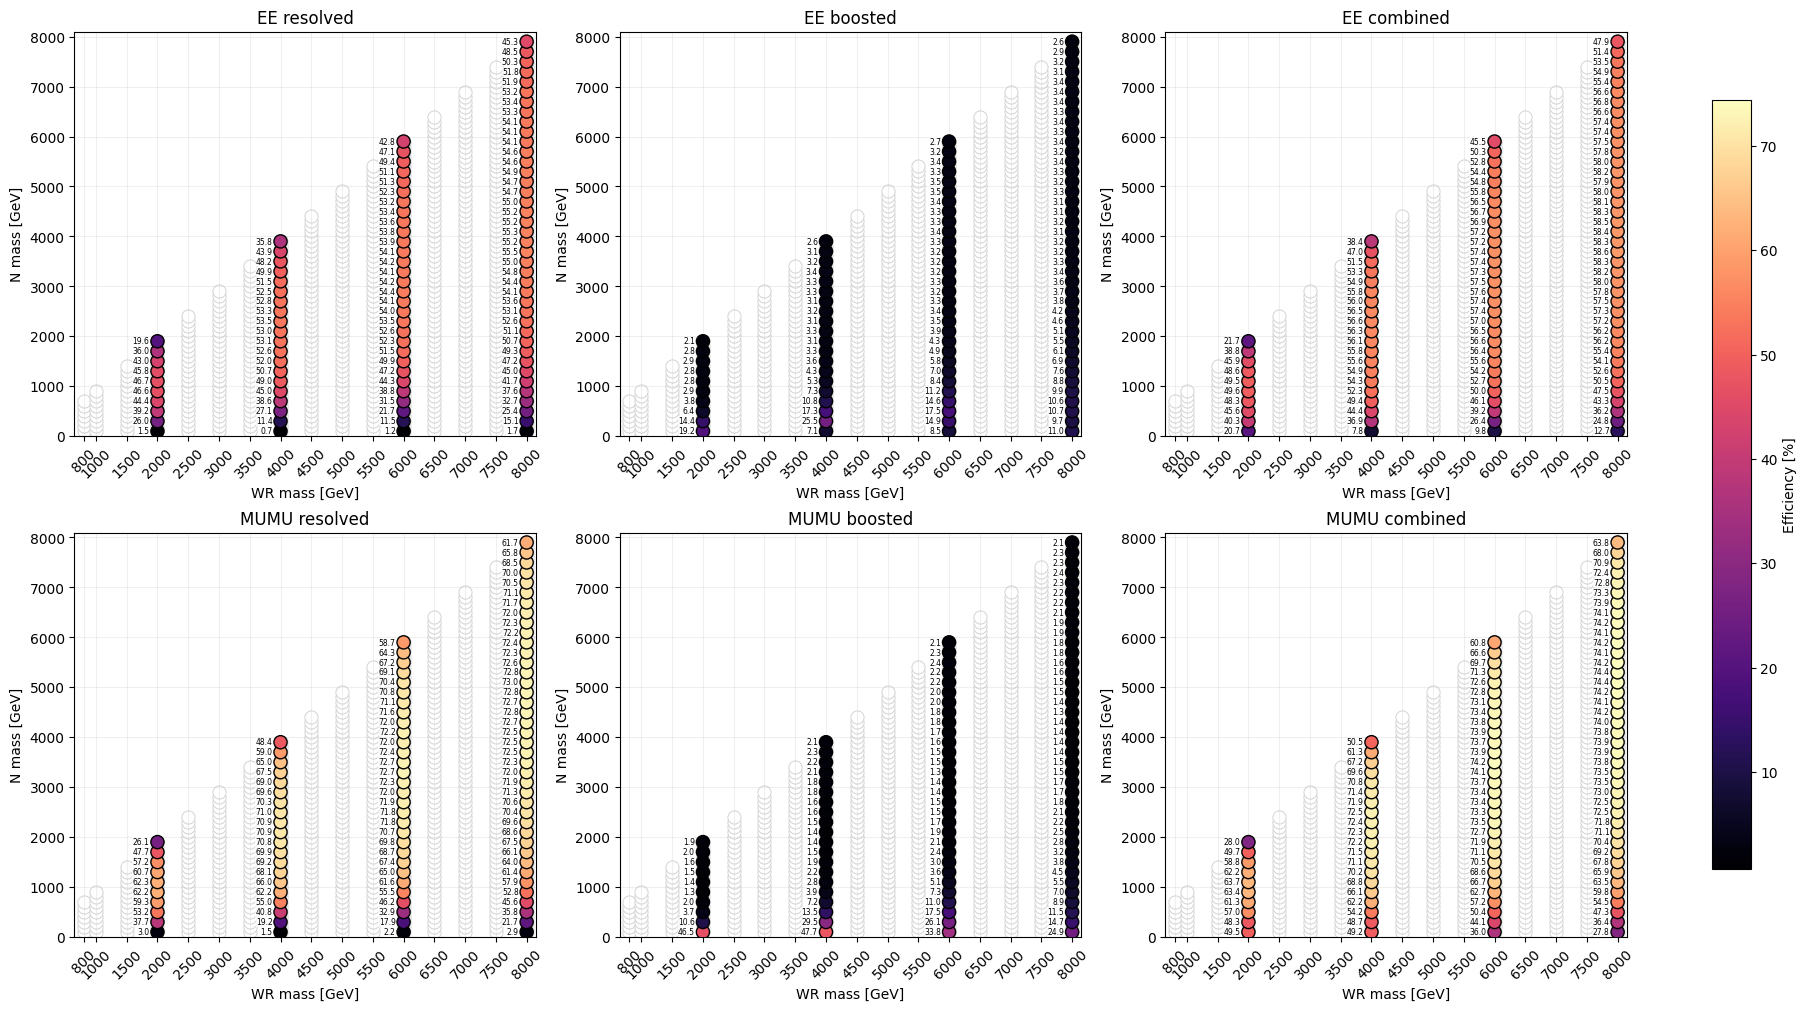

In [17]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import uproot

plot_root_dir = Path('/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023')
root_pattern = re.compile(r'WR(?P<wr>\d+)N(?P<n>\d+)(?P<channel>EE|MM)\.root')
channel_map = {'EE': 'ee', 'MM': 'mumu'}
channels = ['ee', 'mumu']
regions = ['resolved', 'boosted', 'combined']

plot_wr_values = np.array([800] + list(range(1000, 8001, 500)))
highlight_wr_values = [2000, 4000, 6000, 8000]
resolved_hist_candidates = ['Central/Cutflow_for_Resolved_SR', 'Central/Cutflow_for_reseolved_SR']
boosted_hist_candidates = ['Central/Cutflow_for_Boosted_SR']


def extract_efficiency(root_path, hist_candidates, use_penultimate_bin=False):
    with uproot.open(root_path) as root_file:
        hist_name = next((name for name in hist_candidates if name in root_file), None)
        if hist_name is None:
            return np.nan

        values = root_file[hist_name].values(flow=False)
        if len(values) < 2:
            return np.nan

        denominator = float(values[1])
        numerator = float(values[-2] if use_penultimate_bin and len(values) >= 2 else values[-1])
        return np.nan if denominator <= 0 else numerator / denominator


eff_lookup = {(channel, region): {} for channel in channels for region in regions}

for root_path in sorted(plot_root_dir.glob('WR*N*.root')):
    match = root_pattern.fullmatch(root_path.name)
    if not match:
        continue

    wr_mass = int(match.group('wr'))
    n_mass = int(match.group('n'))
    channel = channel_map[match.group('channel')]
    if wr_mass > 8000:
        continue

    resolved_eff = extract_efficiency(root_path, resolved_hist_candidates)
    boosted_eff = extract_efficiency(root_path, boosted_hist_candidates, use_penultimate_bin=True)
    combined_eff = np.nan if np.isnan(resolved_eff) and np.isnan(boosted_eff) else np.nansum([resolved_eff, boosted_eff])

    eff_lookup[(channel, 'resolved')][(wr_mass, n_mass)] = resolved_eff
    eff_lookup[(channel, 'boosted')][(wr_mass, n_mass)] = boosted_eff
    eff_lookup[(channel, 'combined')][(wr_mass, n_mass)] = combined_eff

background_points = []
for wr_mass in plot_wr_values:
    for n_mass in range(100, wr_mass, 100):
        background_points.append((wr_mass, n_mass))
background_points = np.array(background_points)


def build_highlight_df(channel, region):
    highlight_points = []
    lookup = eff_lookup[(channel, region)]

    for wr_mass in highlight_wr_values:
        for n_mass in range(100, wr_mass, 200):
            eff_value = lookup.get((wr_mass, n_mass), np.nan)
            if not np.isnan(eff_value):
                eff_value *= 100.0
            highlight_points.append((wr_mass, n_mass, eff_value))

    return pd.DataFrame(highlight_points, columns=['wr_mass', 'n_mass', 'efficiency'])


highlight_dfs = {}
all_valid_eff = []
for channel in channels:
    for region in regions:
        highlight_df = build_highlight_df(channel, region)
        highlight_dfs[(channel, region)] = highlight_df
        valid_eff = highlight_df['efficiency'].dropna()
        if not valid_eff.empty:
            all_valid_eff.append(valid_eff)

all_valid_eff = pd.concat(all_valid_eff, ignore_index=True)
norm = colors.Normalize(vmin=all_valid_eff.min(), vmax=all_valid_eff.max())
cmap = plt.cm.magma

marker_size = 90


def draw_panel(ax, channel, region):
    highlight_df = highlight_dfs[(channel, region)]
    valid_mask = highlight_df['efficiency'].notna()

    ax.scatter(
        background_points[:, 0],
        background_points[:, 1],
        s=marker_size,
        facecolors='white',
        edgecolors='lightgray',
        linewidths=0.7,
        zorder=1,
    )

    ax.scatter(
        highlight_df.loc[~valid_mask, 'wr_mass'],
        highlight_df.loc[~valid_mask, 'n_mass'],
        s=marker_size,
        facecolors='white',
        edgecolors='black',
        linewidths=1.0,
        zorder=3,
    )

    if valid_mask.any():
        valid_df = highlight_df.loc[valid_mask].copy()
        filled_colors = cmap(norm(valid_df['efficiency'].to_numpy()))
        ax.scatter(
            valid_df['wr_mass'],
            valid_df['n_mass'],
            facecolors=filled_colors,
            s=marker_size,
            marker='o',
            edgecolors='black',
            linewidths=1.0,
            zorder=4,
        )

        for _, row in valid_df.iterrows():
            ax.text(
                row['wr_mass'] - 130,
                row['n_mass'],
                f"{row['efficiency']:.1f}",
                ha='right',
                va='center',
                fontsize=5.5,
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.15),
                zorder=5,
            )

    ax.set_xlim(650, 8150)
    ax.set_ylim(0, 8100)
    ax.set_xticks(plot_wr_values)
    ax.set_yticks(np.arange(0, 8001, 1000))
    ax.tick_params(axis='x', rotation=45, labelbottom=True)
    ax.tick_params(axis='y', labelleft=True)
    ax.set_xlabel('WR mass [GeV]')
    ax.set_ylabel('N mass [GeV]')
    ax.set_title(f'{channel.upper()} {region}')
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True, constrained_layout=True)

for row, channel in enumerate(channels):
    for col, region in enumerate(regions):
        draw_panel(axes[row, col], channel, region)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.85)
cbar.set_label('Efficiency [%]')

plt.show()
